### Dataset
Dataset with two distinct, intuitive groups:
- Group A: Healthy Lifestyle: Individuals with lower weight, lower blood pressure, and who exercise more.

- Group B: Sedentary Lifestyle: Individuals with higher weight, higher blood pressure, and who exercise less.

### Applying PCA with Python
The goal of PCA is to reduce these four features into a smaller number of "principal components" that capture the most important information in the data.

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate a more realistic and structured dataset
np.random.seed(0) # for reproducibility

# Group A: Healthy Lifestyle (15 individuals)
n_healthy = 15
healthy_data = {
    'Weight (kg)': np.random.normal(loc=65, scale=5, size=n_healthy),
    'Systolic BP': np.random.normal(loc=115, scale=5, size=n_healthy),
    'Diastolic BP': np.random.normal(loc=75, scale=4, size=n_healthy),
    'Weekly Exercise (h)': np.random.normal(loc=5, scale=1, size=n_healthy),
    'Group': 'Healthy'
}

# Group B: Sedentary Lifestyle (15 individuals)
n_sedentary = 15
sedentary_data = {
    'Weight (kg)': np.random.normal(loc=90, scale=6, size=n_sedentary),
    'Systolic BP': np.random.normal(loc=140, scale=7, size=n_sedentary),
    'Diastolic BP': np.random.normal(loc=90, scale=5, size=n_sedentary),
    'Weekly Exercise (h)': np.random.normal(loc=1, scale=0.5, size=n_sedentary),
    'Group': 'Sedentary'
}

# Combine into a single DataFrame
df_healthy = pd.DataFrame(healthy_data)
df_sedentary = pd.DataFrame(sedentary_data)
df = pd.concat([df_healthy, df_sedentary], ignore_index=True)

# Separate features (X) from the label (y)
X = df.drop('Group', axis=1)
y = df['Group']


# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(df)

,Weight (kg),Systolic BP,Diastolic BP,Weekly Exercise (h),Group
0,73.820262,116.668372,75.619790,4.561926,Healthy
1,67.000786,122.470395,76.512650,3.747205,Healthy
2,69.893690,113.974209,71.448857,5.777490,Healthy
3,76.204466,116.565339,67.076814,3.386102,Healthy
4,74.337790,110.729521,73.608351,4.787260,Healthy
5,60.113611,102.235051,75.625396,4.104533,Healthy
6,69.750442,118.268093,79.921163,5.386902,Healthy
7,64.243214,119.322181,79.809519,4.489195,Healthy
8,64.483906,111.289175,73.450693,3.819368,Healthy
9,67.052993,126.348773,73.790789,4.971818,Healthy


In [9]:
# 3. Apply PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Create a DataFrame with the principal components and the group labels
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df = pd.concat([pca_df, y], axis=1)

print("Transformed Data (Principal Components):")
print(pca_df)
print("\n" + "="*30 + "\n")



Transformed Data (Principal Components):
         PC1       PC2      Group
0   1.428470 -0.174724    Healthy
1   1.248281  0.166190    Healthy
2   2.268229 -0.297119    Healthy
3   1.397807 -0.927972    Healthy
4   1.784912 -0.255030    Healthy
5   2.445949  0.826015    Healthy
6   1.587926  0.313677    Healthy
7   1.544538  0.601889    Healthy
8   1.940620  0.265422    Healthy
9   1.598705 -0.172914    Healthy
10  2.615204  0.000021    Healthy
11  2.009666 -0.585486    Healthy
12  2.336535 -0.484297    Healthy
13  1.177336  0.709203    Healthy
14  1.678633 -0.157616    Healthy
15 -1.168890 -0.079003  Sedentary
16 -1.953615  0.537836  Sedentary
17 -1.702312  0.243157  Sedentary
18 -1.315649  0.743211  Sedentary
19 -1.845597 -0.131586  Sedentary
20 -1.405706  0.343117  Sedentary
21 -1.561185  0.186791  Sedentary
22 -2.723229  0.335624  Sedentary
23 -1.023595  0.318754  Sedentary
24 -2.442000 -0.234548  Sedentary
25 -2.939001  0.068031  Sedentary
26 -1.776108 -0.932762  Sedentary
27 -1.8

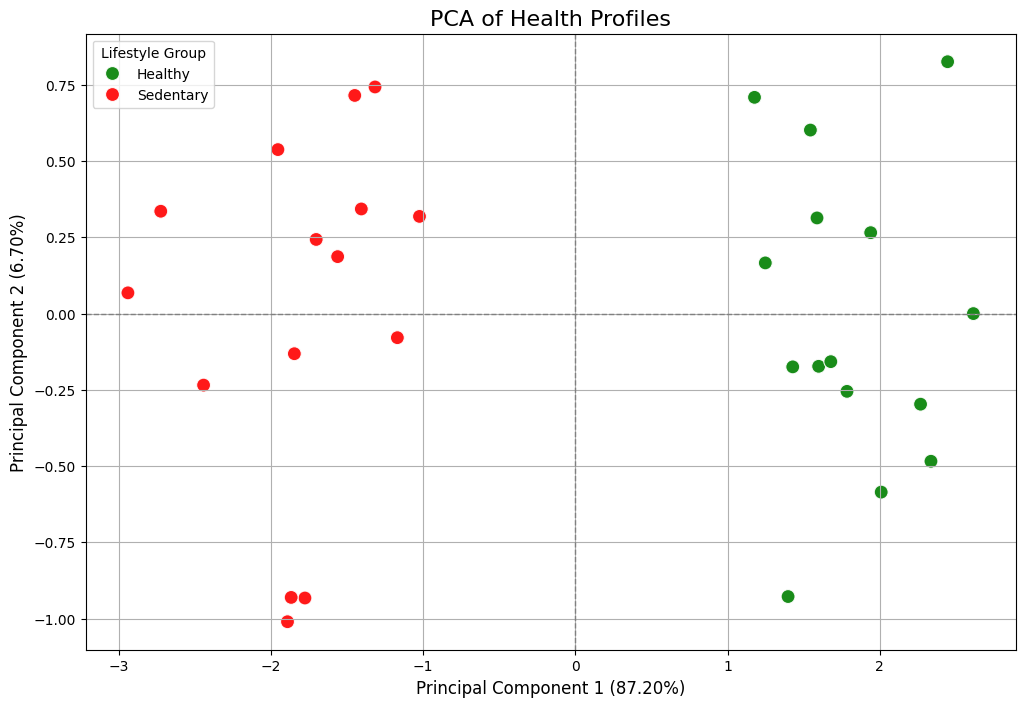

In [10]:
# 4. Create the scatter plot, colored by group
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Group', data=pca_df, s=100, alpha=0.9, palette={'Healthy':'green', 'Sedentary':'red'})

plt.title('PCA of Health Profiles', fontsize=16)
plt.xlabel(f'PC 1 ({explained_variance[0]*100:.2f}%)', fontsize=12)
plt.ylabel(f'PC 2 ({explained_variance[1]*100:.2f}%)', fontsize=12)
plt.legend(title='Lifestyle Group')
plt.grid(True)
plt.axhline(0, color='grey', lw=1, linestyle='--')
plt.axvline(0, color='grey', lw=1, linestyle='--')
plt.show()

### Principal Components: 
The original four columns ('Diastolic BP', 'Systolic BP', 'Weight', 'Height') have been successfully reduced to just two new columns: 'Principal Component 1' and 'Principal Component 2'. Each row in the "Transformed Data" table represents the original data point in this new, simplified 2D space.

In [12]:
# 4. Get the coefficients (loadings)
# The pca.components_ attribute holds the loadings for each principal component.
# Each row represents a principal component, and each column represents a feature.
loadings = pca.components_

# Create a DataFrame to display the loadings clearly
# The columns are the original features, and the index is 
# the principal components.
loadings_df = pd.DataFrame(loadings, columns=X.columns, index=['PC1', 'PC2'])
print("PCA Component Loadings (Coefficients):")
print(loadings_df)

PCA Component Loadings (Coefficients):
     Weight (kg)  Systolic BP  Diastolic BP  Weekly Exercise (h)
PC1    -0.498993     -0.50261     -0.485387             0.512629
PC2    -0.559536     -0.26680      0.781919            -0.065872


## How to Interpret These Coefficients:
These coefficients, or "loadings," reveal the recipe for each principal component and provide a clear, data-driven story about the patterns PCA has discovered.

### Principal Component 1: The "Health & Lifestyle" Index
PC1 = (0.50 * Weight) + (0.50 * Systolic BP) + (0.49 * Diastolic BP) - (0.51 * Weekly Exercise)

- Interpretation: This component is a powerful, interpretable "health and lifestyle index." It has a strong positive correlation with Weight and both Blood Pressure metrics, and a strong negative correlation with Weekly Exercise.

- High PC1 Score: A high positive score on PC1 directly corresponds to an individual with high weight, high blood pressure, and low weekly exercise. This perfectly describes the profile of the "Sedentary" group.

- Low PC1 Score: A low negative score on PC1 indicates the opposite: lower weight, lower blood pressure, and high weekly exercise. This profile perfectly matches the "Healthy" group.

### Principal Component 2: A Secondary Contrast
PC2 = (0.56 * Weight) + (0.27 * Systolic BP) - (0.78 * Diastolic BP) + (0.07 * Weekly Exercise)

- Interpretation: This component captures a more subtle, secondary pattern in the data. It is primarily defined by the strong negative coefficient for Diastolic BP, which it contrasts with the positive coefficient for Weight.

- High PC2 Score: A high score on this component would describe an individual with a high weight but a proportionally low diastolic blood pressure.

- Low PC2 Score: A low score would describe an individual with a very high diastolic blood pressure relative to their weight. This component explains some of the up-and-down variation within each cluster rather than the main separation between them.

- These coefficients provide deep insight into the underlying structure of the data that PCA has uncovered, successfully identifying the primary lifestyle factor that separates the two groups.

In [13]:
# 4. Explained Variance
# This shows how much information (variance) each principal component holds.
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by PC1: {explained_variance[0]:.2f} ({explained_variance[0]*100:.2f}%)")
print(f"Explained variance by PC2: {explained_variance[1]:.2f} ({explained_variance[1]*100:.2f}%)")
print(f"Total variance captured by PC1 and PC2: {sum(explained_variance):.2f} ({sum(explained_variance)*100:.2f}%)")

Explained variance by PC1: 0.87 (87.20%)
Explained variance by PC2: 0.07 (6.70%)
Total variance captured by PC1 and PC2: 0.94 (93.90%)


- Principal Component 1 (PC1) captures a remarkable 87.20% of the total variance (information) from the original four variables.

- Principal Component 2 (PC2) captures an additional 6.70% of the remaining variance.

- Conclusion: Together, the first two principal components capture 93.90% of the information from the original dataset. The overwhelming majority of the data's structure is contained within just the first component, which we identified as the "Health & Lifestyle Index." This confirms that the difference between the "Healthy" and "Sedentary" groups is by far the most significant pattern in the data. We can therefore confidently use this 2D visualization for analysis, knowing it represents the most important story the data has to tell.